# COPER latent embeddings — visualization

Loads **exported** checkpoints (see `utils/export_coper_checkpoint.py`) from `code/COPER`, runs the network up to the **last latent after LayerNorm** (64-D by default), then plots **PCA**, **UMAP**, and optional **t-SNE** colored by mortality label.

**Prerequisite:** export bundles from `notebooks/compare_mortality_mimic3.ipynb` (default **`NITERS=3`** → names like `coper_*_drop0.5_s1_e3.pt`) or manually, e.g.
```bash
.venv-coper/bin/python utils/export_coper_checkpoint.py \
  --repo /path/to/code/COPER \
  --ckpt /path/to/COPER-mimic-F-1_D0.5_S1.ckpt \
  --out-dir artifacts --name coper_1node_drop0.5_s1_e3 \
  --drop 0.5 --random-seed 1
```

For a **2-NODE** checkpoint, use the `_N2.ckpt` file and add `--second-node` to the export command.

Install extras if needed: `pip install umap-learn scikit-learn`

In [8]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)

BENCH = Path("/home/charlesv/Desktop/StatisitcalGenetics/code/COPER").resolve()
if str(BENCH) not in sys.path:
    sys.path.insert(0, str(BENCH))

from utils.coper_embed import latent_before_classifier, latent_grid
from utils.embedding_data_utils import collect_latents, load_xy_split, tensors_to_loader
from utils.load_coper_bundle import load_coper_from_bundle
from utils.viz_utils import run_viz

In [9]:
# ---- Paths: bundles + repo + data ----
ROOT = Path("/home/charlesv/Desktop/StatisitcalGenetics")
MORTALITY_PICKLE = ROOT / "MIMIC" / "mimic3-benchmarks" / "data" / "mortality_for_coper.data"

REPO = ROOT / "code" / "COPER"
RESULTS_ROOT = BENCH / "results"
ARTIFACTS = BENCH / "artifacts"

# Must match compare_mortality_mimic3.ipynb NITERS / export suffix _e{N}
NITERS_BUNDLE = 3
BUNDLE_1NODE = ARTIFACTS / f"coper_1node_drop0.5_s1_e{NITERS_BUNDLE}.pt"
BUNDLE_2NODE = ARTIFACTS / f"coper_2node_drop0.5_s1_e{NITERS_BUNDLE}.pt"
# Optional legacy 1-epoch bundles (no _eN) — used only to refresh slide PNGs *_1epoch.png
LEGACY_BUNDLE_1NODE = ARTIFACTS / "coper_1node_drop0.5_s1.pt"
LEGACY_BUNDLE_2NODE = ARTIFACTS / "coper_2node_drop0.5_s1.pt"

# Prediction dumps written by utils/run_exp.py / utils.evaluate(_uq)
PRED_1NODE_OG = RESULTS_ROOT / "Predictions_COPER-Test-OG-mimic--1-1-0.5.npz"
PRED_1NODE_G = RESULTS_ROOT / "Predictions_COPER-Test-G-mimic--1-1-0.5.npz"
PRED_2NODE_OG = RESULTS_ROOT / "Predictions_COPER-Test-OG-mimic--1-1-0.5_2NODE.npz"
PRED_2NODE_G = RESULTS_ROOT / "Predictions_COPER-Test-G-mimic--1-1-0.5_2NODE.npz"

SPLIT = "val"  # "val" | "test" | "train"
MAX_SAMPLES = 2000  # cap for speed; set None for full split
BATCH_SIZE = 64
RANDOM_STATE = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("DEVICE", DEVICE)

DEVICE cuda


COPER_1NODE Z (2000, 64) y (2000,) pos_rate 0.13750000298023224


/home/charlesv/Desktop/StatisitcalGenetics/code/COPER/.venv-coper/lib64/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Saved figure /home/charlesv/Desktop/StatisitcalGenetics/pictures/coper_1ode_1epoch.png


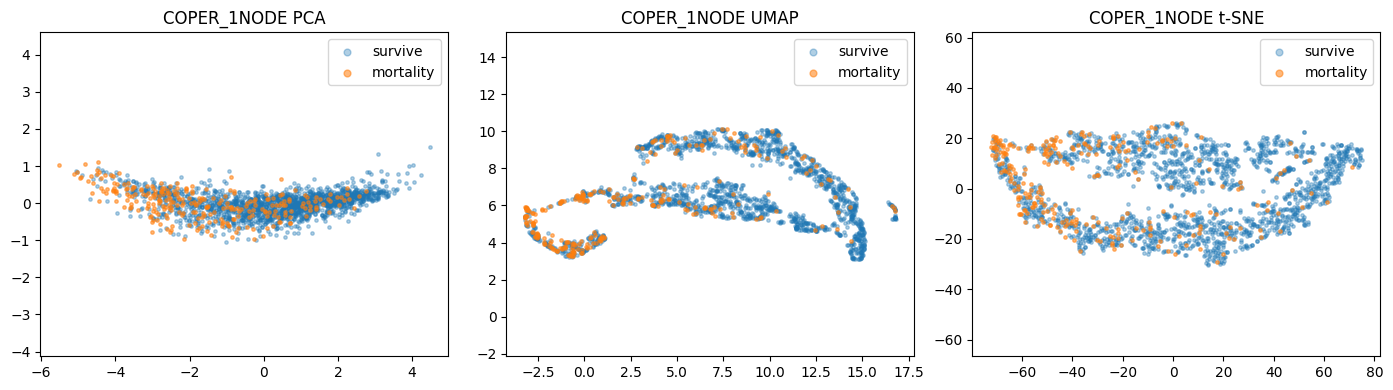

Saved /home/charlesv/Desktop/StatisitcalGenetics/code/COPER/artifacts/latents_COPER_1NODE_val_n2000.npz + meta json
COPER_2NODE Z (2000, 64) y (2000,) pos_rate 0.13750000298023224


/home/charlesv/Desktop/StatisitcalGenetics/code/COPER/.venv-coper/lib64/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Saved figure /home/charlesv/Desktop/StatisitcalGenetics/pictures/coper_2node_1epoch.png


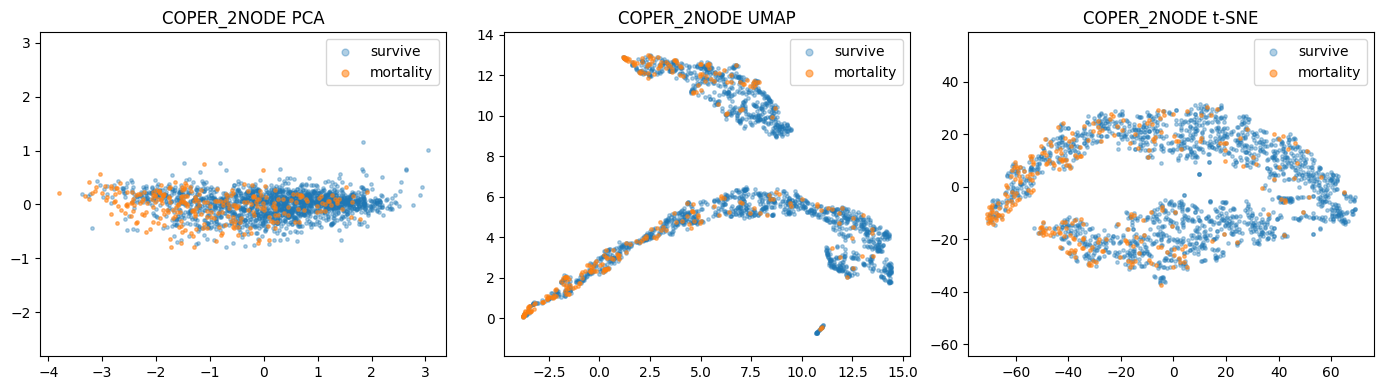

Saved /home/charlesv/Desktop/StatisitcalGenetics/code/COPER/artifacts/latents_COPER_2NODE_val_n2000.npz + meta json
COPER_1NODE Z (2000, 64) y (2000,) pos_rate 0.13750000298023224


/home/charlesv/Desktop/StatisitcalGenetics/code/COPER/.venv-coper/lib64/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Saved figure /home/charlesv/Desktop/StatisitcalGenetics/pictures/coper_1ode_3epoch.png


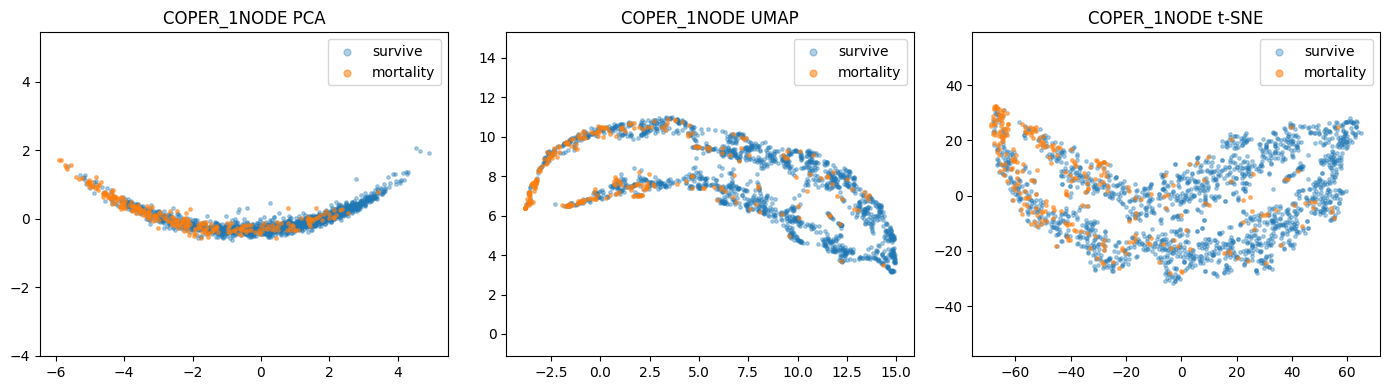

Saved /home/charlesv/Desktop/StatisitcalGenetics/code/COPER/artifacts/latents_COPER_1NODE_val_n2000.npz + meta json
COPER_2NODE Z (2000, 64) y (2000,) pos_rate 0.13750000298023224


/home/charlesv/Desktop/StatisitcalGenetics/code/COPER/.venv-coper/lib64/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Saved figure /home/charlesv/Desktop/StatisitcalGenetics/pictures/coper_2node_3epoch.png


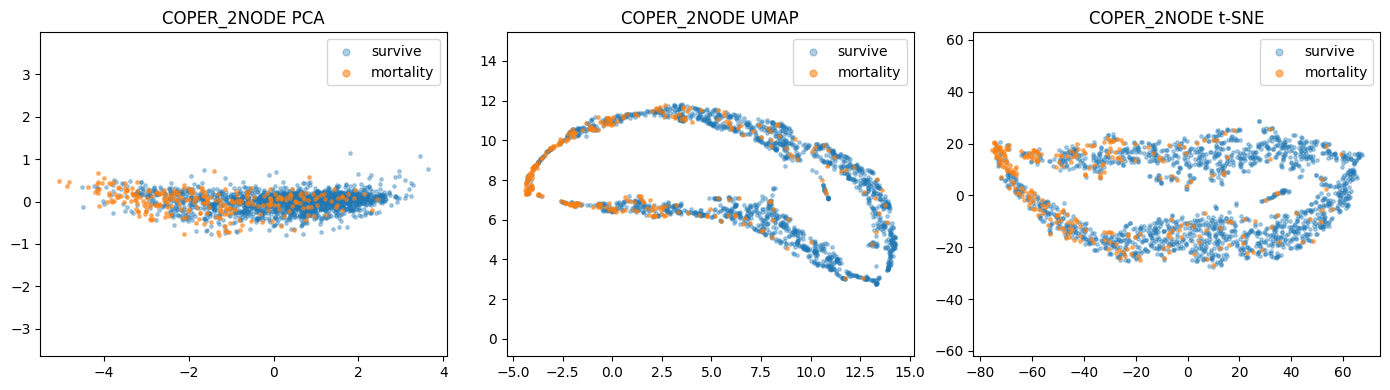

Saved /home/charlesv/Desktop/StatisitcalGenetics/code/COPER/artifacts/latents_COPER_2NODE_val_n2000.npz + meta json


In [10]:
assert MORTALITY_PICKLE.is_file(), MORTALITY_PICKLE
ARTIFACTS.mkdir(parents=True, exist_ok=True)
# Slides / repo root: embedding comparison figures (PCA | UMAP | t-SNE)
PICTURES = ROOT / "pictures"
PICTURES.mkdir(parents=True, exist_ok=True)

_viz_kw = dict(
    repo_root=REPO,
    device=DEVICE,
    mortality_pickle=MORTALITY_PICKLE,
    split=SPLIT,
    max_samples=MAX_SAMPLES,
    batch_size=BATCH_SIZE,
    random_state=RANDOM_STATE,
    artifacts_dir=ARTIFACTS,
    load_coper_from_bundle=load_coper_from_bundle,
    load_xy_split=load_xy_split,
    tensors_to_loader=lambda X_np, y_np, max_samples, batch_size: tensors_to_loader(
        X_np, y_np, max_samples, batch_size, RANDOM_STATE, DEVICE
    ),
    collect_latents=lambda model, loader: collect_latents(model, loader, latent_before_classifier),
)

if LEGACY_BUNDLE_1NODE.is_file():
    run_viz(
        bundle_path=LEGACY_BUNDLE_1NODE,
        label="COPER_1NODE",
        save_figure_path=PICTURES / "coper_1ode_1epoch.png",
        **_viz_kw,
    )
else:
    print("Skip 1-epoch figure (legacy bundle missing):", LEGACY_BUNDLE_1NODE)

if LEGACY_BUNDLE_2NODE.is_file():
    run_viz(
        bundle_path=LEGACY_BUNDLE_2NODE,
        label="COPER_2NODE",
        save_figure_path=PICTURES / "coper_2node_1epoch.png",
        **_viz_kw,
    )
else:
    print("Skip 1-epoch figure (legacy bundle missing):", LEGACY_BUNDLE_2NODE)

viz_1node = run_viz(
    bundle_path=BUNDLE_1NODE,
    label="COPER_1NODE",
    save_figure_path=PICTURES / "coper_1ode_3epoch.png",
    **_viz_kw,
)

viz_2node = run_viz(
    bundle_path=BUNDLE_2NODE,
    label="COPER_2NODE",
    save_figure_path=PICTURES / "coper_2node_3epoch.png",
    **_viz_kw,
)

In [11]:
# ---- Model metadata + parameter count + convergence/runtime summary ----

def _bundle_stats(bundle_path: Path, label: str):
    if not bundle_path.is_file():
        return None
    raw = torch.load(bundle_path, map_location="cpu")
    if isinstance(raw, dict) and "model_state_dict" in raw:
        state = raw["model_state_dict"]
        meta = raw.get("meta", {})
    else:
        state = raw if isinstance(raw, dict) else {}
        meta = {}

    n_params = int(sum(v.numel() for v in state.values())) if isinstance(state, dict) else np.nan
    h = meta.get("hyperparams", {})
    return {
        "model": label,
        "bundle": str(bundle_path),
        "n_params": n_params,
        "fold": h.get("fold"),
        "drop": h.get("drop"),
        "random_seed": h.get("random_seed"),
        "num_latents": h.get("num_latents"),
        "latent_dim": h.get("latent_dim"),
        "rec_layers": h.get("rec_layers"),
        "units": h.get("units"),
        "emb_dim": h.get("emb_dim"),
        "second_node": h.get("second_node"),
    }


bundle_summary = pd.DataFrame([
    x for x in [
        _bundle_stats(BUNDLE_1NODE, "COPER_1NODE"),
        _bundle_stats(BUNDLE_2NODE, "COPER_2NODE"),
    ] if x is not None
])

if not bundle_summary.empty:
    print("Model hyperparameters + number of parameters")
    display(bundle_summary)

# Runtime / convergence proxy from benchmark table (generated by compare notebook)
raw_csv = RESULTS_ROOT / "tables" / "mimic3_repo_comparison_raw.csv"
if raw_csv.is_file():
    run_df = pd.read_csv(raw_csv)
    conv = run_df[[
        "arch_id", "seed", "drop", "runtime_sec",
        "test_og_auroc", "test_og_auprc", "test_g_auroc", "test_g_auprc"
    ]].copy()
    conv["runtime_min"] = conv["runtime_sec"] / 60.0
    print("Convergence/runtime and prediction metrics from latest benchmark run")
    display(conv.sort_values(["arch_id", "seed", "drop"]))
else:
    print(f"No benchmark table found at {raw_csv}. Run compare notebook first.")

Model hyperparameters + number of parameters


,model,bundle,n_params,fold,drop,random_seed,num_latents,latent_dim,rec_layers,units,emb_dim,second_node
0,COPER_1NODE,/home/charlesv/Desktop/StatisitcalGenetics/cod...,223233,-1,0.5,1,48,64,3,128,32,False
1,COPER_2NODE,/home/charlesv/Desktop/StatisitcalGenetics/cod...,289345,-1,0.5,1,48,64,3,128,32,True


Convergence/runtime and prediction metrics from latest benchmark run


,arch_id,seed,drop,runtime_sec,test_og_auroc,test_og_auprc,test_g_auroc,test_g_auprc,runtime_min
0,coper_1node,1,0.5,440.875837,0.8088,0.3813,0.8049,0.3743,7.347931
1,coper_2node,1,0.5,878.294891,0.7923,0.3580,0.8064,0.3806,14.638248


## Prediction-level comparison from saved `.npz`

This section reloads raw prediction dumps produced during training (`results/Predictions_*.npz`) and compares 1-NODE vs 2-NODE on the same patients.

It reports:
- AUROC / AUPRC / Brier score from saved probabilities
- per-case agreement where one model is correct and the other is wrong
- examples where one model strongly out-scores the other

In [12]:
def _best_threshold_gmean(y_true, y_prob):
    fpr, tpr, thr = roc_curve(y_true, y_prob)
    g = np.sqrt(tpr * (1.0 - fpr))
    i = int(np.nanargmax(g))
    return float(thr[i]), float(g[i])


def load_pred_npz(path: Path):
    if not path.is_file():
        raise FileNotFoundError(path)
    with np.load(path, allow_pickle=True) as d:
        keys = set(d.files)

        # Preferred explicit format
        if {"y_true", "pred_prob"}.issubset(keys):
            y_true = np.asarray(d["y_true"]).reshape(-1).astype(int)
            y_prob = np.asarray(d["pred_prob"]).reshape(-1)
            return y_true, y_prob

        # Backward format seen in current runs: only probabilities in arr_0
        # Recover labels from mortality pickle test split.
        if "arr_0" in keys:
            y_prob = np.asarray(d["arr_0"]).reshape(-1)
            _, y_test = load_xy_split(MORTALITY_PICKLE, "test")
            y_true = np.asarray(y_test).reshape(-1).astype(int)
            if y_true.shape[0] != y_prob.shape[0]:
                raise ValueError(
                    f"Length mismatch for {path.name}: y_true={y_true.shape[0]} vs y_prob={y_prob.shape[0]}"
                )
            return y_true, y_prob

    raise KeyError(f"Unsupported prediction npz format in {path}")


def summarize_preds(tag: str, y_true, y_prob):
    thr, gmax = _best_threshold_gmean(y_true, y_prob)
    y_hat = (y_prob >= thr).astype(int)
    return {
        "tag": tag,
        "n": int(y_true.size),
        "pos_rate": float(y_true.mean()),
        "auroc": float(roc_auc_score(y_true, y_prob)),
        "auprc": float(average_precision_score(y_true, y_prob)),
        "brier": float(brier_score_loss(y_true, y_prob)),
        "best_thr_gmean": thr,
        "best_gmean": gmax,
        "acc_at_best_thr": float((y_hat == y_true).mean()),
    }


def compare_casewise(name_a, y_true_a, p_a, name_b, y_true_b, p_b):
    assert np.array_equal(y_true_a, y_true_b), "Prediction files are not aligned on y_true"
    y = y_true_a

    thr_a, _ = _best_threshold_gmean(y, p_a)
    thr_b, _ = _best_threshold_gmean(y, p_b)
    h_a = (p_a >= thr_a).astype(int)
    h_b = (p_b >= thr_b).astype(int)

    a_correct = h_a == y
    b_correct = h_b == y

    a_only = np.where(a_correct & ~b_correct)[0]
    b_only = np.where(b_correct & ~a_correct)[0]

    print(f"{name_a} only-correct cases: {a_only.size}")
    print(f"{name_b} only-correct cases: {b_only.size}")

    # Big confidence gaps (not necessarily correctness): useful to inspect opposite behavior.
    gap = p_a - p_b
    top_a = np.argsort(-gap)[:10]
    top_b = np.argsort(gap)[:10]

    df_a = pd.DataFrame({
        "idx": top_a,
        "y_true": y[top_a],
        f"{name_a}_prob": p_a[top_a],
        f"{name_b}_prob": p_b[top_a],
        "prob_gap_a_minus_b": gap[top_a],
        f"{name_a}_pred": h_a[top_a],
        f"{name_b}_pred": h_b[top_a],
    })
    df_b = pd.DataFrame({
        "idx": top_b,
        "y_true": y[top_b],
        f"{name_a}_prob": p_a[top_b],
        f"{name_b}_prob": p_b[top_b],
        "prob_gap_a_minus_b": gap[top_b],
        f"{name_a}_pred": h_a[top_b],
        f"{name_b}_pred": h_b[top_b],
    })
    return {
        "a_only_idx": a_only,
        "b_only_idx": b_only,
        "a_only_df": pd.DataFrame({"idx": a_only}),
        "b_only_df": pd.DataFrame({"idx": b_only}),
        "top_a_gap_df": df_a,
        "top_b_gap_df": df_b,
    }


# ---- Load and compare OG predictions ----
y_1_og, p_1_og = load_pred_npz(PRED_1NODE_OG)
y_2_og, p_2_og = load_pred_npz(PRED_2NODE_OG)

metrics_og = pd.DataFrame([
    summarize_preds("1NODE_OG", y_1_og, p_1_og),
    summarize_preds("2NODE_OG", y_2_og, p_2_og),
])
display(metrics_og)

og_cases = compare_casewise("1NODE", y_1_og, p_1_og, "2NODE", y_2_og, p_2_og)
print("\nTop cases where 1NODE >> 2NODE (probability gap):")
display(og_cases["top_a_gap_df"])
print("\nTop cases where 2NODE >> 1NODE (probability gap):")
display(og_cases["top_b_gap_df"])

# ---- Load and compare G predictions ----
y_1_g, p_1_g = load_pred_npz(PRED_1NODE_G)
y_2_g, p_2_g = load_pred_npz(PRED_2NODE_G)

metrics_g = pd.DataFrame([
    summarize_preds("1NODE_G", y_1_g, p_1_g),
    summarize_preds("2NODE_G", y_2_g, p_2_g),
])
display(metrics_g)

g_cases = compare_casewise("1NODE", y_1_g, p_1_g, "2NODE", y_2_g, p_2_g)
print("\nTop cases where 1NODE >> 2NODE (probability gap):")
display(g_cases["top_a_gap_df"])
print("\nTop cases where 2NODE >> 1NODE (probability gap):")
display(g_cases["top_b_gap_df"])

,tag,n,pos_rate,auroc,auprc,brier,best_thr_gmean,best_gmean,acc_at_best_thr
0,1NODE_OG,3236,0.115575,0.808797,0.381315,0.085787,0.107882,0.735979,0.722497
1,2NODE_OG,3236,0.115575,0.792284,0.358002,0.150037,0.393341,0.724212,0.706119


1NODE only-correct cases: 130
2NODE only-correct cases: 77

Top cases where 1NODE >> 2NODE (probability gap):


,idx,y_true,1NODE_prob,2NODE_prob,prob_gap_a_minus_b,1NODE_pred,2NODE_pred
0,2761,0,0.022308,0.036680,-0.014372,0,0
1,1967,0,0.020840,0.101190,-0.080351,0,0
2,3063,0,0.019837,0.109003,-0.089166,0,0
3,3036,0,0.020752,0.109961,-0.089209,0,0
4,3194,0,0.020323,0.111942,-0.091619,0,0
5,2157,0,0.022106,0.114048,-0.091942,0,0
6,1272,0,0.021595,0.116161,-0.094566,0,0
7,2265,0,0.023135,0.118684,-0.095549,0,0
8,3177,0,0.020998,0.117204,-0.096206,0,0
9,771,0,0.023473,0.120167,-0.096693,0,0



Top cases where 2NODE >> 1NODE (probability gap):


,idx,y_true,1NODE_prob,2NODE_prob,prob_gap_a_minus_b,1NODE_pred,2NODE_pred
0,2898,0,0.135383,0.604971,-0.469587,1,1
1,155,0,0.197895,0.662234,-0.464339,1,1
2,2275,0,0.181901,0.636067,-0.454166,1,1
3,1073,0,0.192040,0.645861,-0.453821,1,1
4,699,1,0.111447,0.564198,-0.452751,1,1
5,591,0,0.141351,0.593963,-0.452612,1,1
6,613,0,0.152193,0.598707,-0.446514,1,1
7,2272,0,0.159585,0.603577,-0.443992,1,1
8,3025,0,0.168996,0.612161,-0.443165,1,1
9,1487,0,0.152563,0.592066,-0.439503,1,1


,tag,n,pos_rate,auroc,auprc,brier,best_thr_gmean,best_gmean,acc_at_best_thr
0,1NODE_G,3236,0.115575,0.804928,0.374252,0.086143,0.098306,0.735960,0.728368
1,2NODE_G,3236,0.115575,0.806374,0.380626,0.086056,0.090011,0.732271,0.712299


1NODE only-correct cases: 85
2NODE only-correct cases: 33

Top cases where 1NODE >> 2NODE (probability gap):


,idx,y_true,1NODE_prob,2NODE_prob,prob_gap_a_minus_b,1NODE_pred,2NODE_pred
0,2066,0,0.429918,0.305652,0.124266,1,1
1,357,1,0.499778,0.390792,0.108985,1,1
2,1155,1,0.386060,0.278950,0.107110,1,1
3,2371,0,0.370707,0.265439,0.105268,1,1
4,2711,1,0.534677,0.434382,0.100295,1,1
5,1617,0,0.255394,0.155523,0.099871,1,1
6,1385,1,0.416992,0.318570,0.098422,1,1
7,2604,1,0.350696,0.252491,0.098205,1,1
8,444,0,0.241345,0.147094,0.094251,1,1
9,4,0,0.286830,0.197760,0.089069,1,1



Top cases where 2NODE >> 1NODE (probability gap):


,idx,y_true,1NODE_prob,2NODE_prob,prob_gap_a_minus_b,1NODE_pred,2NODE_pred
0,2513,1,0.143032,0.287962,-0.144930,1,1
1,784,0,0.173681,0.279302,-0.105622,1,1
2,2907,0,0.112280,0.215953,-0.103673,1,1
3,1108,0,0.286558,0.378134,-0.091576,1,1
4,2452,0,0.235353,0.325349,-0.089996,1,1
5,837,0,0.274646,0.360761,-0.086114,1,1
6,1543,0,0.263741,0.349711,-0.085970,1,1
7,282,1,0.238890,0.324452,-0.085562,1,1
8,2710,0,0.293841,0.379187,-0.085346,1,1
9,1098,1,0.370016,0.451216,-0.081200,1,1


## Latent-space diagnostics (class separation)

Simple quantitative checks on the latent vectors used above:
- centroid distance between mortality/non-mortality groups
- within-class spread
- nearest cross-class examples for quick qualitative inspection

In [13]:
def latent_stats(viz_obj):
    if viz_obj is None:
        return None
    Z = np.asarray(viz_obj["Z"], dtype=np.float32)
    y = np.asarray(viz_obj["y"]).astype(int)

    z0 = Z[y == 0]
    z1 = Z[y == 1]
    c0 = z0.mean(axis=0)
    c1 = z1.mean(axis=0)

    between = float(np.linalg.norm(c1 - c0))
    spread0 = float(np.mean(np.linalg.norm(z0 - c0, axis=1)))
    spread1 = float(np.mean(np.linalg.norm(z1 - c1, axis=1)))

    return {
        "label": viz_obj["label"],
        "n": int(Z.shape[0]),
        "n_pos": int((y == 1).sum()),
        "n_neg": int((y == 0).sum()),
        "centroid_dist": between,
        "spread_neg": spread0,
        "spread_pos": spread1,
        "separation_ratio": between / (0.5 * (spread0 + spread1) + 1e-8),
    }


def nearest_cross_class_pairs(viz_obj, top_k=10):
    Z = np.asarray(viz_obj["Z"], dtype=np.float32)
    y = np.asarray(viz_obj["y"]).astype(int)
    idx0 = np.where(y == 0)[0]
    idx1 = np.where(y == 1)[0]
    if idx0.size == 0 or idx1.size == 0:
        return pd.DataFrame(columns=["idx_neg", "idx_pos", "distance"])

    # Pairwise distance between classes (can be large if MAX_SAMPLES is large)
    d = np.linalg.norm(Z[idx0][:, None, :] - Z[idx1][None, :, :], axis=2)
    flat = np.argsort(d, axis=None)[:top_k]
    i, j = np.unravel_index(flat, d.shape)
    return pd.DataFrame({
        "idx_neg": idx0[i],
        "idx_pos": idx1[j],
        "distance": d[i, j],
    })


latent_summary = pd.DataFrame([
    x for x in [latent_stats(viz_1node), latent_stats(viz_2node)] if x is not None
])
display(latent_summary)

if viz_1node is not None:
    print("Nearest cross-class pairs (1NODE):")
    display(nearest_cross_class_pairs(viz_1node, top_k=10))

if viz_2node is not None:
    print("Nearest cross-class pairs (2NODE):")
    display(nearest_cross_class_pairs(viz_2node, top_k=10))

,label,n,n_pos,n_neg,centroid_dist,spread_neg,spread_pos,separation_ratio
0,COPER_1NODE,2000,275,1725,2.461707,1.835630,2.007694,1.281030
1,COPER_2NODE,2000,275,1725,1.737421,1.341115,1.539113,1.206447


Nearest cross-class pairs (1NODE):


,idx_neg,idx_pos,distance
0,457,1353,0.117375
1,64,1214,0.170285
2,708,454,0.174028
3,583,327,0.174398
4,1010,1993,0.183350
5,1839,1335,0.187630
6,1399,1335,0.194523
7,211,1335,0.200365
8,1057,26,0.204481
9,1496,1454,0.205537


Nearest cross-class pairs (2NODE):


,idx_neg,idx_pos,distance
0,1512,454,0.062466
1,1047,1752,0.086074
2,105,1752,0.088870
3,778,1353,0.110886
4,1451,1752,0.120590
5,889,327,0.123370
6,648,544,0.124114
7,1206,1217,0.124730
8,457,1353,0.126852
9,1552,1752,0.127991


## Optional: latent grid (Perceiver slots)

Uncomment to average over time and plot heatmap of mean latent across slots (48×64) for a small batch.

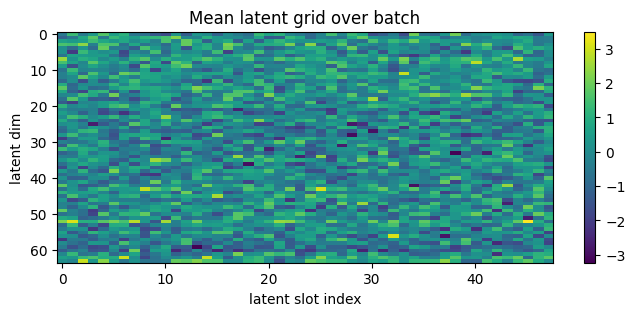

In [14]:
model, _ = load_coper_from_bundle(BUNDLE_1NODE, REPO, device=DEVICE)
loader = tensors_to_loader(
    *load_xy_split(MORTALITY_PICKLE, "val")[:2],
    64,
    32,
    random_state=RANDOM_STATE,
    device=DEVICE,
)
batch = next(iter(loader))
X, tp = batch["X"], batch["tp"]
G = latent_grid(model, X, [tp], [tp], [tp]).cpu().numpy()  # (B, L, D)
fig, ax = plt.subplots(figsize=(8, 3))
im = ax.imshow(G.mean(axis=0).T, aspect="auto", cmap="viridis")
plt.colorbar(im, ax=ax)
ax.set_xlabel("latent slot index")
ax.set_ylabel("latent dim")
plt.title("Mean latent grid over batch")
plt.show()